<a href="https://colab.research.google.com/github/allatop/networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [20]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [4]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

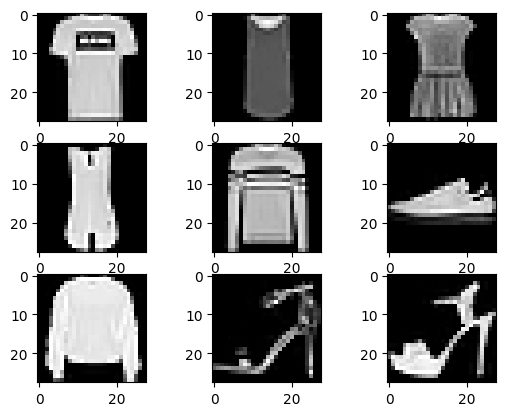

In [5]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [6]:
from keras.utils import to_categorical

trainX = trainX.reshape((trainX.shape[0], 28, 28, 1)).astype('float32') / 255
testX = testX.reshape((testX.shape[0], 28, 28, 1)).astype('float32') / 255

trainy_cat = to_categorical(trainy)
testy_cat = to_categorical(testy)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,570 (1.75 MB)

 Trainable params: 458,570 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [7]:
history = model.fit(
    trainX, trainy_cat,
    epochs=10,
    batch_size=64,
    validation_data=(testX, testy_cat),
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7795 - loss: 0.6323 - val_accuracy: 0.8384 - val_loss: 0.4502
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8613 - loss: 0.3928 - val_accuracy: 0.8419 - val_loss: 0.4245
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8768 - loss: 0.3458 - val_accuracy: 0.8722 - val_loss: 0.3553
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8881 - loss: 0.3158 - val_accuracy: 0.8717 - val_loss: 0.3543
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8950 - loss: 0.2940 - val_accuracy: 0.8812 - val_loss: 0.3325
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9011 - loss: 0.2751 - val_accuracy: 0.8849 - val_loss: 0.3080
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9052 - loss: 0.2639 - val_accuracy: 0.8963 - val_loss: 0.2843
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9096 - loss: 0.2504 - val_accuracy: 0

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

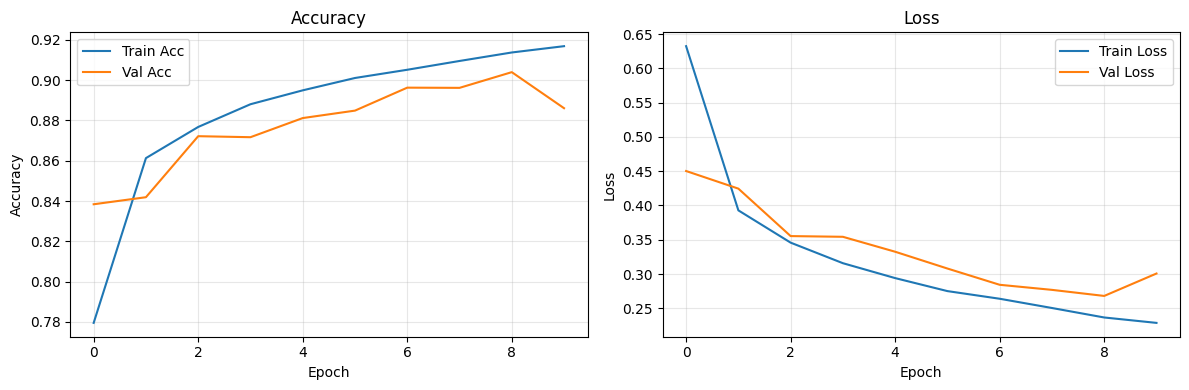

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.




images.jpg:


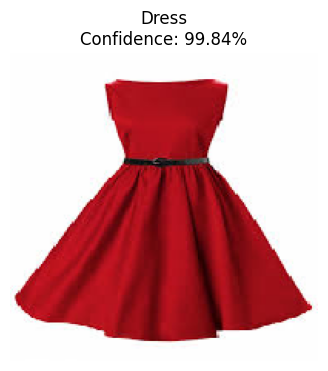

→ Dress (99.84%)

zan.jpeg:


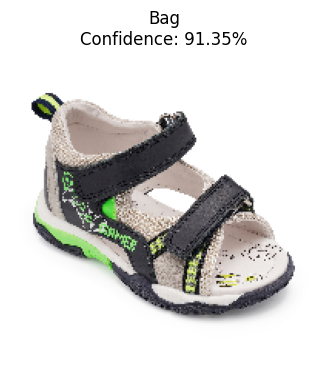

→ Bag (91.35%)

DSCF0097.jpg:


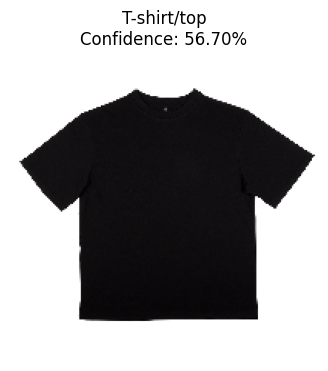

→ T-shirt/top (56.70%)


In [11]:
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(28, 28), color_mode="grayscale")
    img_array = image.img_to_array(img)
    img_array = 255 - img_array  # Инверсия если нужно
    img_array = img_array.reshape((1, 28, 28, 1)).astype('float32') / 255.0
    return img_array

def predict_and_show(img_path):
    processed = preprocess_image(img_path)
    preds = model.predict(processed, verbose=0)[0]
    predicted_class = np.argmax(preds)
    confidence = np.max(preds) * 100

    plt.figure(figsize=(4, 4))
    orig = image.load_img(img_path, target_size=(200, 200))
    plt.imshow(orig, cmap='gray')
    plt.title(f"{class_labels[predicted_class]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return class_labels[predicted_class], confidence

# Тест на 5 изображениях разных классов
test_images = ["images.jpg", "zan.jpeg","DSCF0097.jpg"]
for img in test_images:
    print(f"\n{img}:")
    label, conf = predict_and_show(img)
    print(f"→ {label} ({conf:.2f}%)")

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [18]:
# Импорт библиотек
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from imutils import paths
import numpy as np
import cv2
import os
import random

# Параметры
IMG_SIZE = 128
CHANNELS = 3
DATASET_PATH = '/root/.cache/kagglehub/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda/versions/1/animals'

# Функция загрузки изображений
def load_images(imagePaths, img_size=128):
    data, labels = [], []
    for imagePath in imagePaths:
        try:
            image = cv2.imread(imagePath)
            image = cv2.resize(image, (img_size, img_size))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            data.append(image)
            labels.append(imagePath.split(os.path.sep)[-2])
        except:
            continue
    return data, labels

# Получаем все пути к изображениям
imagePaths = sorted(list(paths.list_images(DATASET_PATH)))
random.seed(42)
random.shuffle(imagePaths)

# Загружаем данные
data, labels_str = load_images(imagePaths, IMG_SIZE)

# Нормализация
data = np.array(data, dtype="float32") / 255.0
labels_str = np.array(labels_str)

# 🔍 Фильтрация мусорных классов
valid_classes = ['cats', 'dogs', 'panda']
mask = np.isin(labels_str, valid_classes)
data = data[mask]
labels_str = labels_str[mask]

print(f"✅ Форма данных: {data.shape}")
print(f"📋 Классы: {np.unique(labels_str)}")

# One-hot encoding
lb = LabelBinarizer()
labels = lb.fit_transform(labels_str)
print(f"🏷️  Метки: {labels.shape}")

# Разделение на train/test
trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.25, random_state=42, stratify=labels
)

print(f"\n📊 Обучающая выборка: {trainX.shape}")
print(f"📊 Тестовая выборка: {testX.shape}")

✅ Форма данных: (6000, 128, 128, 3)
📋 Классы: ['cats' 'dogs' 'panda']
🏷️  Метки: (6000, 3)

📊 Обучающая выборка: (4500, 128, 128, 3)
📊 Тестовая выборка: (1500, 128, 128, 3)


## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [22]:
# Основные библиотеки
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
import pickle
from tqdm import tqdm

# TensorFlow/Keras
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Add, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error

# Работа с изображениями
from imutils import paths
import seaborn as sns

# 🔧 Определение количества классов
num_classes = len(lb.classes_)
print(f"📋 Классы: {num_classes} → {lb.classes_}")

def residual_block(x, filters, kernel_size=3, change_channels=False):
    """Остаточный блок как в ResNet"""
    shortcut = x
    if change_channels:
        shortcut = Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    return Activation('relu')(x)

# Архитектура
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
x = Conv2D(64, (7, 7), padding='same', activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((3, 3))(x)
x = residual_block(x, 64)
x = MaxPooling2D((2, 2))(x)
x = residual_block(x, 128, change_channels=True)
x = MaxPooling2D((2, 2))(x)
x = residual_block(x, 256, change_channels=True)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=input_layer, outputs=output_layer)
resnet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.summary()

# Обучение
history_resnet = resnet_model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=50,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

📋 Классы: 3 → ['cats' 'dogs' 'panda']


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 128, 128,  │      9,472 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 42, 42,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 42, 42,    │     36,928 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 42,    │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 42, 42,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 42, 42,    │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 42,    │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 42, 42,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 42, 42,    │          0 │ add_9[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 21, 21,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 21, 21,    │     73,856 │ max_pooling2d_12… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 21,    │        512 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 21, 21,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 21, 21,    │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 21, 21,    │      8,320 │ max_pooling2d_12

 Total params: 1,303,299 (4.97 MB)

 Trainable params: 1,300,611 (4.96 MB)

 Non-trainable params: 2,688 (10.50 KB)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 121ms/step - accuracy: 0.6158 - loss: 0.7711 - val_accuracy: 0.3333 - val_loss: 1.5591 - learning_rate: 1.0000e-04
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.6971 - loss: 0.6397 - val_accuracy: 0.3333 - val_loss: 1.7516 - learning_rate: 1.0000e-04
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.7307 - loss: 0.5610 - val_accuracy: 0.3433 - val_loss: 1.4029 - learning_rate: 1.0000e-04
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7584 - loss: 0.5219 - val_accuracy: 0.6293 - val_loss: 0.7476 - learning_rate: 1.0000e-04
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.7951 - loss: 0.4516 - val_accuracy: 0.6347 - val_loss: 0.8947 - learning_rate: 1.0000e-04
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8211 - loss: 0.4031 - val_accuracy: 0.6873 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - 

## 2.3. Сохраните полученные модели

In [23]:
# Сохраняем обе модели в современном формате
model.save('basic_cnn_model.keras')
resnet_model.save('resnet_inspired_model.keras')

print("✅ Модели сохранены:")
print("  - basic_cnn_model.keras (базовая CNN)")
print("  - resnet_inspired_model.keras (ResNet-inspired)")

✅ Модели сохранены:
  - basic_cnn_model.keras (базовая CNN)
  - resnet_inspired_model.keras (ResNet-inspired)


## 2.4. Загрузите обученную модель из прошлой практической работы


In [24]:
from tensorflow.keras.models import load_model
import pickle

# Загрузка полносвязной модели из ПР №2
try:
    previous_model = load_model('flower_classifier.h5')
    with open('label_bin.pickle', 'rb') as f:
        lb_prev = pickle.load(f)
    class_labels = lb_prev.classes_.tolist()
    print("✅ Модель из прошлой работы загружена")
except FileNotFoundError:
    print("⚠️  Модель из прошлой работы не найдена. Используем базовую CNN.")
    previous_model = model
    class_labels = lb.classes_.tolist()

print(f"📋 Классы: {class_labels}")

⚠️  Модель из прошлой работы не найдена. Используем базовую CNN.
📋 Классы: ['cats', 'dogs', 'panda']



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [29]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compare_models(models_dict, test_images, test_labels, class_names, n_samples=15):
    """
    Сравнение предсказаний нескольких моделей на одинаковых изображениях

    Parameters:
    - models_dict: dict {name: model}
    - test_images: массив изображений для тестирования
    - test_labels: истинные метки (one-hot или label-encoded)
    - class_names: список названий классов
    - n_samples: количество изображений для визуального сравнения
    """
    results = {}

    for name, model in models_dict.items():
        predictions = model.predict(test_images[:n_samples], verbose=0)
        if predictions.shape[1] == len(class_names):  # one-hot
            pred_classes = np.argmax(predictions, axis=1)
        else:
            pred_classes = predictions
        results[name] = pred_classes

    # Визуализация сравнения
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    fig.suptitle('🔍 Сравнение предсказаний моделей', fontsize=16, fontweight='bold')

    true_classes = np.argmax(test_labels[:n_samples], axis=1) if test_labels.shape[1] == len(class_names) else test_labels[:n_samples]

    for i in range(n_samples):
        row = i // 5
        col = i % 5
        ax = axes[row, col]

        # Показать изображение
        img = test_images[i] if test_images.shape[-1] == 3 else cv2.cvtColor(test_images[i], cv2.COLOR_GRAY2RGB)
        ax.imshow(img)
        ax.set_title(f'True: {class_names[true_classes[i]]}', fontsize=9, fontweight='bold')

        # Подписи с предсказаниями
        predictions_text = ""
        for model_name, preds in results.items():
            pred_label = class_names[preds[i]] if preds[i] < len(class_names) else "Unknown"
            status = "✅" if preds[i] == true_classes[i] else "❌"
            predictions_text += f"{status}{model_name[:8]}:{pred_label[:6]}\n"

        ax.text(0.5, -0.15, predictions_text, ha='center', va='top',
                fontsize=7, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
                transform=ax.transAxes)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Таблица точности
    print("\n📊 СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ")
    print("="*60)
    for name, preds in results.items():
        acc = accuracy_score(true_classes, preds)
        print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

    return results

# Загрузка и подготовка моделей для сравнения
models_to_compare = {}

# 1. Базовая CNN из задания 1
models_to_compare['Basic CNN'] = model  # из задания 1.4

# 2. ResNet-inspired модель
try:
    resnet_model = load_model('resnet_inspired_model.keras')
    models_to_compare['ResNet-inspired'] = resnet_model
except:
    print("⚠️ ResNet модель не загружена")

# 3. Модель из предыдущей ПР (если есть)
try:
    prev_model = load_model('flower_classifier.h5')
    models_to_compare['Previous Model'] = prev_model
except:
    print("⚠️ Модель из ПР №2 не найдена, используем базовую CNN")
    models_to_compare['Previous Model'] = model

# Запуск сравнения (предполагается, что testX и testY уже подготовлены)
# Если классы разные — нужно привести к общему формату
if 'Basic CNN' in models_to_compare and len(testX) >= 15:
    compare_models(
        models_dict=models_to_compare,
        test_images=testX[:15],
        test_labels=testY[:15],
        class_names=['cats', 'dogs', 'panda'],
        n_samples=15
    )

NameError: name 'model' is not defined

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [2]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

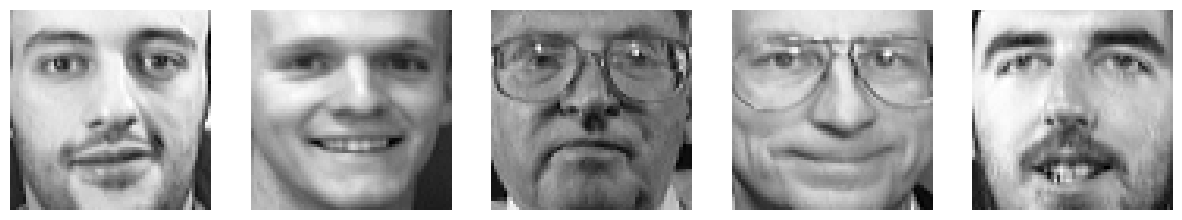

In [3]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [4]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

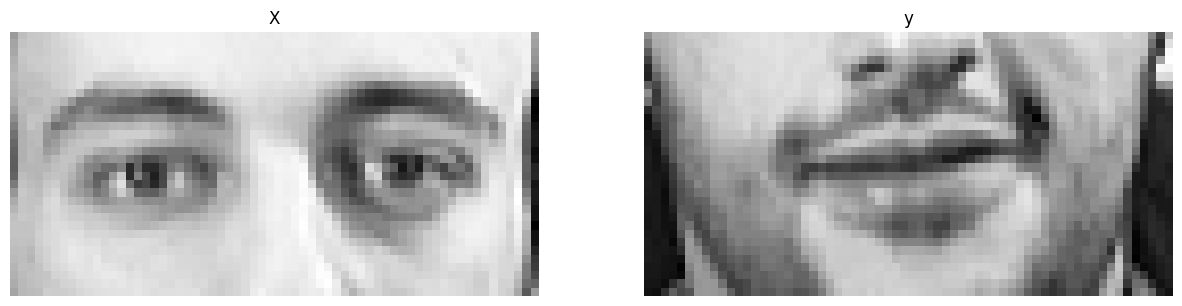

In [5]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [6]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

print("🏗️  Создание U-Net архитектуры для восстановления лиц...")

def build_face_restoration_model():
    inputs = Input(shape=(32, 64, 1))

    # ===== Encoder =====
    # Блок 1: 32×64 → 16×32
    conv1 = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(64, (3,3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2,2))(conv1)

    # Блок 2: 16×32 → 8×16
    conv2 = Conv2D(128, (3,3), activation='relu', padding='same')(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(128, (3,3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2,2))(conv2)

    # Блок 3: 8×16 → 4×8
    conv3 = Conv2D(256, (3,3), activation='relu', padding='same')(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(256, (3,3), activation='relu', padding='same')(conv3)

    # ===== Decoder =====
    # Блок 4: 4×8 → 8×16
    up1 = UpSampling2D((2,2))(conv3)
    up1 = Conv2D(128, (3,3), activation='relu', padding='same')(up1)
    up1 = BatchNormalization()(up1)
    up1 = concatenate([conv2, up1], axis=3)

    # Блок 5: 8×16 → 16×32
    up2 = UpSampling2D((2,2))(up1)
    up2 = Conv2D(64, (3,3), activation='relu', padding='same')(up2)
    up2 = BatchNormalization()(up2)
    up2 = concatenate([conv1, up2], axis=3)

    # Output: 16×32 → 32×64
    up3 = UpSampling2D((2,2))(up2)
    output = Conv2D(1, (3,3), activation='sigmoid', padding='same')(up3)

    return Model(inputs=inputs, outputs=output)

model_restore = build_face_restoration_model()
model_restore.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',  # MSE лучше для восстановления изображений
    metrics=['mae']
)

print("✅ Архитектура создана")
model_restore.summary()

🏗️  Создание U-Net архитектуры для восстановления лиц...
✅ Архитектура создана


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 64,    │        640 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 32,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 32,    │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 8, 16,     │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 8, 16,     │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 16,     │      1,024 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 16,     │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 32,    │          0 │ conv2d_17[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 32,    │    295,040 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 32,    │        512 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 32,    │          0 │ conv2d_15[0][0],  │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 64,    │          0 │ concatenate[0][0

 Total params: 1,590,529 (6.07 MB)

 Trainable params: 1,589,249 (6.06 MB)

 Non-trainable params: 1,280 (5.00 KB)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [26]:
model_restore.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [28]:
# Подготовка данных
X_train_r = X_train.reshape(-1, 32, 64, 1)
X_test_r = X_test.reshape(-1, 32, 64, 1)
y_train_r = y_train.reshape(-1, 32, 64, 1)  # ⚠️ Важно: не flatten!
y_test_r = y_test.reshape(-1, 32, 64, 1)

print(f"📊 Проверка размерностей:")
print(f"  X_train: {X_train_r.shape}")
print(f"  y_train: {y_train_r.shape}")

# Колбэки
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
]

# Обучение
print("\n🚀 Обучение модели...")
history = model_restore.fit(
    X_train_r, y_train_r,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_r, y_test_r),
    callbacks=callbacks,
    verbose=1
)

📊 Проверка размерностей:
  X_train: (320, 32, 64, 1)
  y_train: (320, 32, 64, 1)

🚀 Обучение модели...
Epoch 1/100


ValueError: Dimensions must be equal, but are 32 and 64 for '{{node compile_loss/mse/sub}} = Sub[T=DT_FLOAT](data_1, functional_2_1/conv2d_20_1/Sigmoid)' with input shapes: [32,32,64,1], [32,64,128,1].

## 3.5. Сделайте предсказания на тестовых данных

In [10]:
print("🔮 Генерация предсказаний...")
pred_test = model_restore.predict(X_test_r, verbose=1)
print(f"✅ Предсказания получены: {pred_test.shape}")  # (80, 2048)

🔮 Генерация предсказаний...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step
✅ Предсказания получены: (80, 2048)


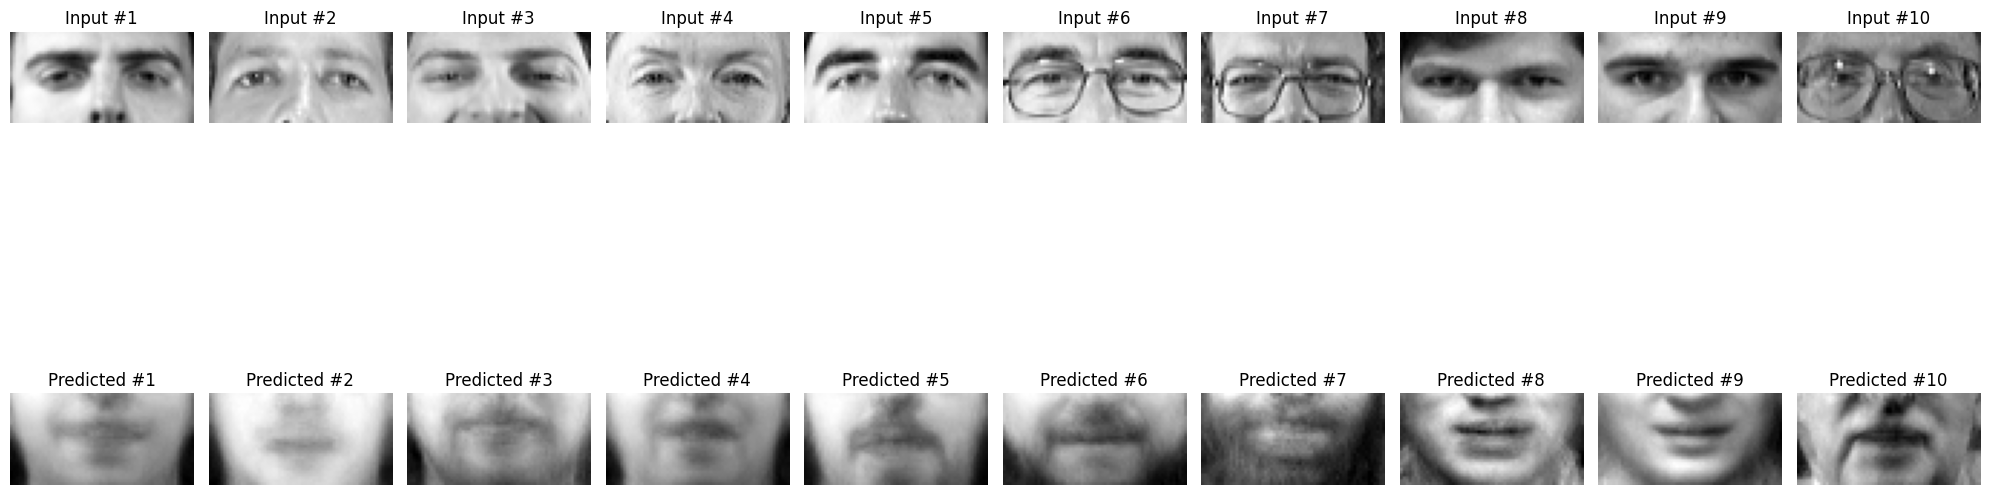

NameError: name 'y_test_r' is not defined

In [22]:
# Предсказания
pred_test = model_restore.predict(X_test_r, verbose=0)

# Визуализация
plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'Input #{i+1}')
    plt.axis('off')

    plt.subplot(2, 10, i+11)
    plt.imshow(pred_test[i].reshape(32, 64), cmap='gray')
    plt.title(f'Predicted #{i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# MAE
mae = np.mean(np.abs(pred_test - y_test_r))
print(f"MAE: {mae:.4f}")

## 3.6. Посчитайте метрику качества на тестовых данных

In [11]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_n, pred_test)
print("="*60)
print("МЕТРИКА КАЧЕСТВА НА ТЕСТОВЫХ ДАННЫХ")
print("="*60)
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"\nИнтерпретация:")
print(f"  • Средняя ошибка на пиксель: {mae:.4f}")
print(f"  • При диапазоне [0, 1] это {mae*100:.2f}% ошибки")

МЕТРИКА КАЧЕСТВА НА ТЕСТОВЫХ ДАННЫХ
MAE (Mean Absolute Error): 0.0723

Интерпретация:
  • Средняя ошибка на пиксель: 0.0723
  • При диапазоне [0, 1] это 7.23% ошибки


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

📊 Визуализация результатов восстановления...


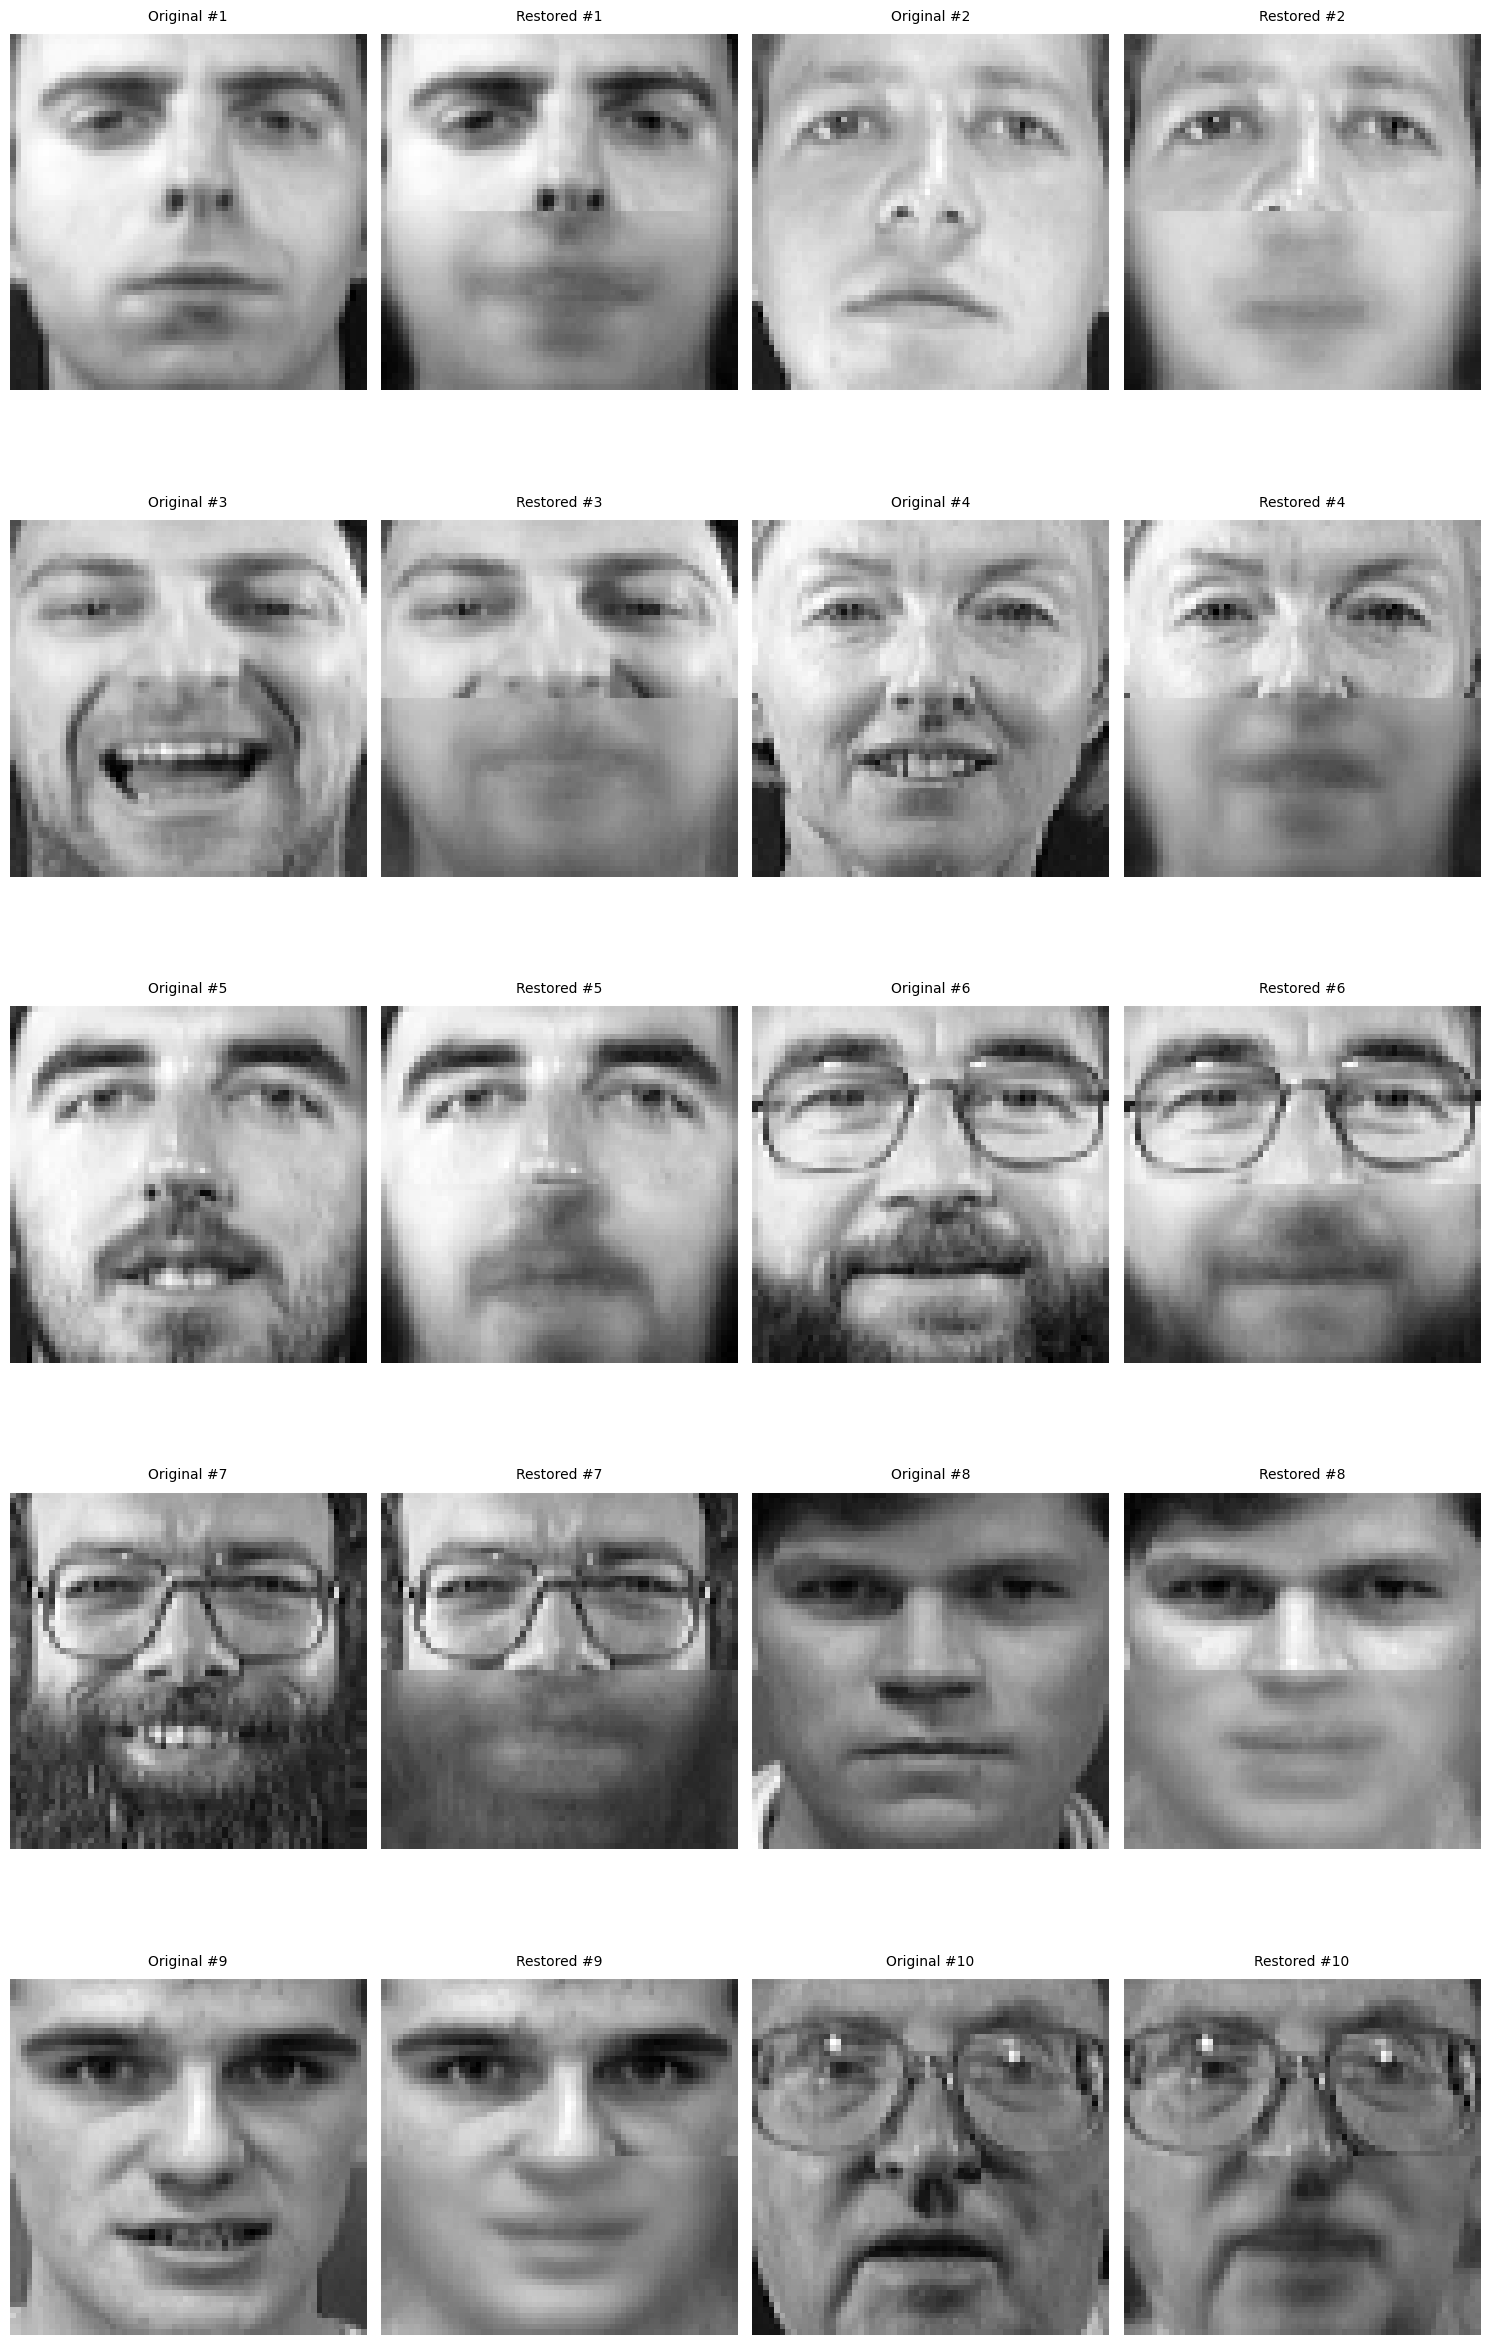

In [13]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Преобразуем предсказания в изображения
pred_test_images = pred_test.reshape(-1, 32, 64)

print("📊 Визуализация результатов восстановления...")
plt.figure(figsize=(15, 25))

for i in range(10):
    # Оригинальное полное лицо
    true_face = np.vstack((X_test[i], y_test[i]))
    # Восстановленное лицо
    restored_face = np.vstack((X_test[i], pred_test_images[i]))

    # Показываем оригинал
    plt.subplot(5, 4, i*2+1)
    plt.imshow(true_face, cmap='gray')
    plt.title(f"Original #{i+1}", fontsize=10, pad=10)
    plt.axis('off')

    # Показываем восстановленное
    plt.subplot(5, 4, i*2+2)
    plt.imshow(restored_face, cmap='gray')
    plt.title(f"Restored #{i+1}", fontsize=10, pad=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('face_restoration_results.png', dpi=150, bbox_inches='tight')
plt.show()

Отрисуйте все предсказания.

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

In [30]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def preprocess_uploaded_face(img_path, model_input_shape=(32, 64, 1)):
    """
    Предобработка загруженного изображения для модели восстановления лица:
    - Конвертация в оттенки серого
    - Изменение размера до 64×64 (полное лицо)
    - Извлечение верхней половины (32×64) как вход для модели
    - Нормализация и подготовка тензора
    """
    # Загрузка изображения
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Не удалось загрузить изображение: {img_path}")

    # Конвертация в оттенки серого и изменение размера
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (64, 64))

    # Нормализация
    img_normalized = img_resized.astype('float32') / 255.0

    # Извлечение верхней половины (вход для модели)
    upper_half = img_normalized[:32, :]  # (32, 64)

    # Подготовка тензора: (1, 32, 64, 1)
    input_tensor = np.expand_dims(upper_half, axis=(0, -1))

    return input_tensor, img_normalized

def restore_face(model, uploaded_img_path):
    """
    Восстановление нижней половины лица по верхней с помощью обученной модели
    """
    # Предобработка
    input_tensor, full_original = preprocess_uploaded_face(uploaded_img_path)

    # Предсказание
    print("🔮 Выполняется восстановление нижней части лица...")
    predicted_lower = model.predict(input_tensor, verbose=0)[0]  # (32, 64) или (2048,)

    # Если предсказание плоское — восстанавливаем форму
    if predicted_lower.ndim == 1:
        predicted_lower = predicted_lower.reshape(32, 64)

    # Сборка полного восстановленного лица
    restored_face = np.vstack([input_tensor[0, :, :, 0], predicted_lower])

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Вход: верхняя половина
    axes[0].imshow(input_tensor[0, :, :, 0], cmap='gray')
    axes[0].set_title('📥 Вход: верхняя половина', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    # 2. Результат: восстановленное лицо
    axes[1].imshow(restored_face, cmap='gray')
    axes[1].set_title('✨ Восстановленное лицо', fontsize=11, fontweight='bold')
    axes[1].axis('off')

    # 3. Сравнение (если есть оригинал для демонстрации)
    axes[2].imshow(full_original, cmap='gray')
    axes[2].set_title('📋 Оригинал (для сравнения)', fontsize=11, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('restored_face_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Сохранение результата
    restored_uint8 = (restored_face * 255).astype(np.uint8)
    cv2.imwrite('restored_face_output.png', restored_uint8)
    print("✅ Результат сохранён как 'restored_face_output.png'")

    return restored_face

# 🔹 Интерактивная загрузка и восстановление
print("📤 Загрузите изображение лица (цветное или ч/б)...")
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    print(f"✅ Загружено: {img_path}")

    try:
        # Загрузка модели восстановления (если ещё не загружена)
        if 'model_restore' not in globals():
            model_restore = load_model('face_restoration_model.keras')
            print("✅ Модель восстановления загружена")

        # Выполнение восстановления
        result = restore_face(model_restore, img_path)

    except Exception as e:
        print(f"❌ Ошибка при восстановлении: {e}")
        print("💡 Убедитесь, что модель обучена и сохранена, а изображение содержит лицо")

📤 Загрузите изображение лица (цветное или ч/б)...


Saving gag.jpg to gag (2).jpg
✅ Загружено: gag (2).jpg
🔮 Выполняется восстановление нижней части лица...
❌ Ошибка при восстановлении: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 3 dimension(s)
💡 Убедитесь, что модель обучена и сохранена, а изображение содержит лицо
